In [2]:
import os
import cv2
import time
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import torch.nn as nn
from sklearn import svm
from sklearn.model_selection import train_test_split

start_time = time.time()
# 加载ResNet-18模型
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model.load_state_dict(torch.load('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/resnet18_d1.pth'))   #加载训练完保存好的模型
model = nn.Sequential(*list(model.children())[:-1])
model.eval()  # 设置为评估模式

def build_gaussian_pyramid(image, levels):
    pyramid = [image]
    for _ in range(levels-1):
        image = cv2.pyrDown(image)
        pyramid.append(image)
    return pyramid

# 定义函数来提取图像的特征
def extract_features(image, transform, model):
    # 对图像进行预处理
    image = transform(image)
    image = torch.unsqueeze(image, 0)

    # 提取特征
    with torch.no_grad():
        features = model(image)

    features = torch.flatten(features, start_dim=1)
    features = features.numpy()
    return features

# 定义数据集路径和转换函数
input_folder = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 定义空列表来保存提取的特征和对应的标签
levels=4
features_list = []
labels_list = []

# 遍历数据集中的图像，并提取特征
folders = ['hole', 'broken', 'float', 'norm']

for folder_name in folders:
    folder_path = os.path.join(input_folder, folder_name)
    image_files = os.listdir(folder_path)

    for image_file in image_files:
        image_path = folder_path + '/' + image_file
        image = cv2.imread(image_path)
        
        pyramid = build_gaussian_pyramid(image, levels)

        # 提取第一个尺度的特征
        features1 = extract_features(Image.fromarray(pyramid[0]), transform, model)

        # 提取第二个尺度的特征
        features2 = extract_features(Image.fromarray(pyramid[1]), transform, model)
        features3 = extract_features(Image.fromarray(pyramid[2]), transform, model)
        features4 = extract_features(Image.fromarray(pyramid[3]), transform, model)

        # 将两个尺度的特征进行汇总
        combined_features = np.concatenate((features1, features2), axis=1)

        # 添加到特征列表和标签列表
        features_list.append(combined_features)
        if 'hole' in folder_name:
            labels_list.append(0)  # 根据你的数据集，添加相应的标签
        elif 'broken' in folder_name:
            labels_list.append(1)
        elif 'float' in folder_name:
            labels_list.append(2)
        elif 'norm' in folder_name:
            labels_list.append(3)
features = np.vstack(features_list)
labels = np.array(labels_list)

# 将特征和标签分割为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

for Nk in ['','linear','rbf','poly','sigmoid']:
    for Nc in [1,10,100,1000]:
        clf = svm.SVC(kernel=Nk, C=Nc)
        clf.fit(X_train, y_train)

        # 使用测试集评估分类器的性能
        accuracy = clf.score(X_test, y_test)
        print('kernel: {}, C: {}, Accuracy: {:.2f}%'.format(Nk,Nc,accuracy*100))

# 记录结束时间
end_time = time.time()
execution_time = end_time - start_time
print(execution_time)

ValueError: '' is not in list

In [3]:
import time
from sklearn.metrics import accuracy_score

# 定义数据集路径和转换函数
input_folder = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 定义空列表来保存提取的特征和对应的标签
levels=4
features_list = []
labels_list = []

# 遍历数据集中的图像，并提取特征
folders = ['hole', 'broken', 'float', 'norm']

for folder_name in folders:
    folder_path = os.path.join(input_folder, folder_name)
    image_files = os.listdir(folder_path)

    for image_file in image_files:
        image_path = folder_path + '/' + image_file
        image = cv2.imread(image_path)
        
        pyramid = build_gaussian_pyramid(image, levels)

        # 提取第一个尺度的特征
        features1 = extract_features(Image.fromarray(pyramid[0]), transform, model)

        # 提取第二个尺度的特征
        features2 = extract_features(Image.fromarray(pyramid[1]), transform, model)
        features3 = extract_features(Image.fromarray(pyramid[2]), transform, model)
        features4 = extract_features(Image.fromarray(pyramid[3]), transform, model)

        # 将两个尺度的特征进行汇总
        combined_features = np.concatenate((features1, features2), axis=1)
        # 添加到特征列表和标签列表
        features_list.append(combined_features)
        if 'hole' in folder_name:
            labels_list.append(0)  # 根据你的数据集，添加相应的标签
        elif 'broken' in folder_name:
            labels_list.append(1)
        elif 'float' in folder_name:
            labels_list.append(2)
        elif 'norm' in folder_name:
            labels_list.append(3)
features = np.vstack(features_list)
labels = np.array(labels_list)

# 将特征和标签分割为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)
# 使用测试集评估分类器的性能
clf = svm.SVC(kernel='linear', C=1000)
clf.fit(X_train, y_train)
pred_labels = clf.predict(X_test)
accuracy = accuracy_score(y_test, pred_labels)
print('kernel: {}, C: {}, Accuracy: {:.2f}%'.format(Nk,Nc,accuracy*100))


kernel: , C: 1, Accuracy: 98.20%


In [3]:
import joblib
joblib.dump(clf, 'svm_model.pkl')

['svm_model.pkl']

In [4]:
import os
import cv2
import time
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import torch.nn as nn
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
start_time = time.time()
def build_gaussian_pyramid(image, levels):
    pyramid = [image]
    for _ in range(levels-1):
        image = cv2.pyrDown(image)
        pyramid.append(image)
    return pyramid

# 定义函数来提取图像的特征
def extract_features(image, transform, model):
    # 对图像进行预处理
    image = transform(image)
    image = torch.unsqueeze(image, 0)

    # 提取特征
    with torch.no_grad():
        features = model(image)

    features = torch.flatten(features, start_dim=1)
    features = features.numpy()
    return features

# 定义数据集路径和转换函数
input_folder = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 定义空列表来保存提取的特征和对应的标签
X_trainlist = []
y_trainlist = []
X_testlist = []
y_testlist = []
levels=4
# 遍历数据集中的图像，并提取特征
folders = ['test/hole', 'test/broken', 'test/float', 'test/norm',
               'train/hole', 'train/broken', 'train/float', 'train/norm',
               'val/hole', 'val/broken', 'val/float', 'val/norm']

for folder_name in folders:
    if 'train' in folder_name:
        folder_path = os.path.join(input_folder, folder_name)
        image_files = os.listdir(folder_path)

        for image_file in image_files:
            image_path = folder_path + '/' + image_file
            image = cv2.imread(image_path)

            pyramid = build_gaussian_pyramid(image, levels)

            # 提取第一个尺度的特征
            features1 = extract_features(Image.fromarray(pyramid[0]), transform, model)

            # 提取第二个尺度的特征
            features2 = extract_features(Image.fromarray(pyramid[1]), transform, model)
            features3 = extract_features(Image.fromarray(pyramid[2]), transform, model)
            features4 = extract_features(Image.fromarray(pyramid[3]), transform, model)

            # 将两个尺度的特征进行汇总
            combined_features = np.concatenate((features1, features2), axis=1)

            # 添加到特征列表和标签列表
            X_trainlist.append(combined_features)
            if 'hole' in folder_name:
                y_trainlist.append(0)  # 根据你的数据集，添加相应的标签
            elif 'broken' in folder_name:
                y_trainlist.append(1)
            elif 'float' in folder_name:
                y_trainlist.append(2)
            elif 'norm' in folder_name:
                y_trainlist.append(3)
    elif 'val' in folder_name:
        folder_path = os.path.join(input_folder, folder_name)
        image_files = os.listdir(folder_path)

        for image_file in image_files:
            image_path = folder_path + '/' + image_file
            image = cv2.imread(image_path)

            pyramid = build_gaussian_pyramid(image, levels)

            # 提取第一个尺度的特征
            features1 = extract_features(Image.fromarray(pyramid[0]), transform, model)

            # 提取第二个尺度的特征
            features2 = extract_features(Image.fromarray(pyramid[1]), transform, model)
            features3 = extract_features(Image.fromarray(pyramid[2]), transform, model)
            features4 = extract_features(Image.fromarray(pyramid[3]), transform, model)

            # 将两个尺度的特征进行汇总
            combined_features = np.concatenate((features1, features2), axis=1)
            # 添加到特征列表和标签列表
            X_testlist.append(combined_features)
            if 'hole' in folder_name:
                y_testlist.append(0)  # 根据你的数据集，添加相应的标签
            elif 'broken' in folder_name:
                y_testlist.append(1)
            elif 'float' in folder_name:
                y_testlist.append(2)
            elif 'norm' in folder_name:
                y_testlist.append(3)
X_train = np.vstack(X_trainlist)
X_test = np.vstack(X_testlist)
y_train = np.array(y_trainlist)
y_test = np.array(y_testlist)

pred_labels = clf.predict(X_test)
accuracy = accuracy_score(y_test, pred_labels)
# 使用测试集评估分类器的性能
print("Accuracy:", accuracy)
# 记录结束时间
end_time = time.time()
# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(pred_labels))

Accuracy: 0.9535714285714286
0.14370031356811525


In [8]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('Dual_resnet18SVM_con.png', dpi=300)
    plt.tight_layout()

In [9]:
cnf_matrix = confusion_matrix(y_test, pred_labels)
print(cnf_matrix)

[[66  3  0  1]
 [ 0 64  1  5]
 [ 0  0 68  2]
 [ 0  0  1 69]]


Normalized confusion matrix
[[0.94285714 0.04285714 0.         0.01428571]
 [0.         0.91428571 0.01428571 0.07142857]
 [0.         0.         0.97142857 0.02857143]
 [0.         0.         0.01428571 0.98571429]]


<ipython-input-8-a4357782f55a>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


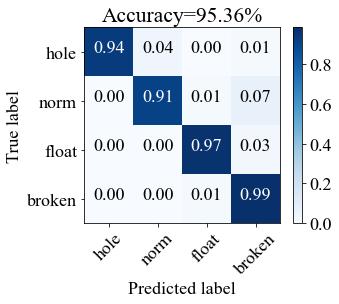

In [10]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred_labels)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)